 MODEL: K-NEAREST NEIGHBORS (KNN)

1. INSTALL LIBRARIES


In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

2. IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

 3. MOUNT GOOGLE DRIVE


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. LOAD DATASET FROM DRIVE

In [9]:
data_path = "/content/drive/MyDrive/ML_Dataset/mobile_price_dataset.csv"
data = pd.read_csv(data_path)

 5. DATA UNDERSTANDING


In [10]:
print("\n===== DATA INFORMATION =====")
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)

print("\n===== FIRST 5 ROWS =====")
print(data.head())

print("\n===== LAST 5 ROWS =====")
print(data.tail())


===== DATA INFORMATION =====
Shape: (891, 12)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

===== FIRST 5 ROWS =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7

6. DATA TYPES & MISSING VALUES


In [11]:
print("\n===== DATA TYPES =====")
print(data.dtypes)

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())


===== DATA TYPES =====
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

===== MISSING VALUES =====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


 7. STATISTICAL SUMMARY


In [12]:
print("\n===== STATISTICAL SUMMARY =====")
print(data.describe())


===== STATISTICAL SUMMARY =====
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


 8. DATA VISUALIZATION

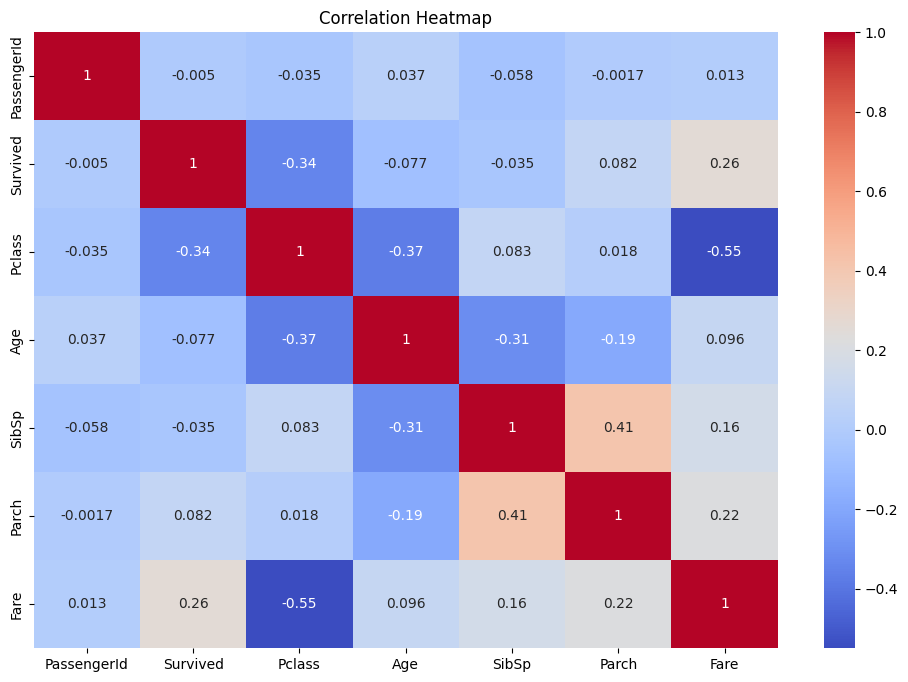

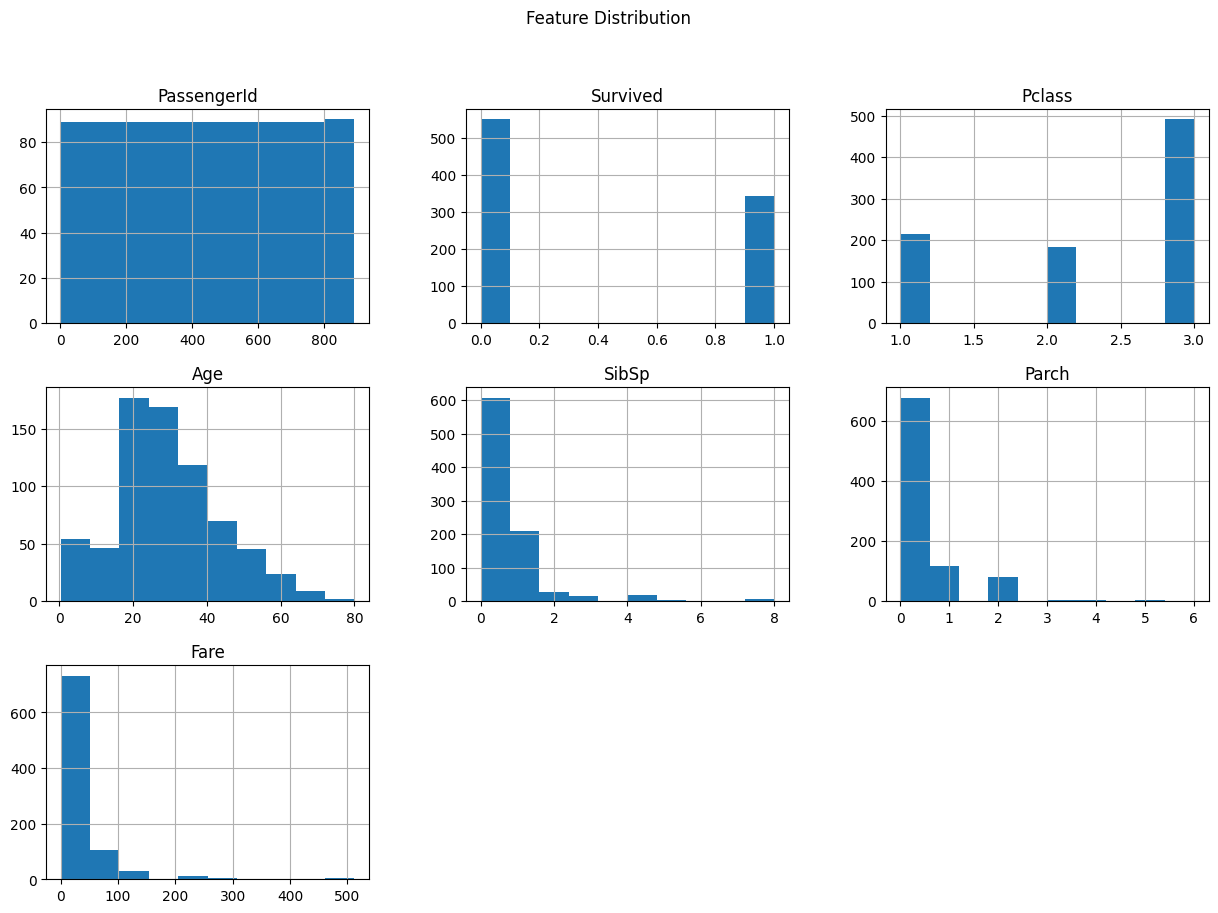

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

data.hist(figsize=(15,10))
plt.suptitle("Feature Distribution")
plt.show()

9. FEATURE & TARGET

In [16]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

10. FEATURE SCALING (IMPORTANT FOR KNN)

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

11. 80:20 SPLIT

In [21]:
print("\n===== KNN MODEL (80:20) =====")

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


===== KNN MODEL (80:20) =====


 12. MODEL TRAINING (80:20)

In [22]:
model_80 = KNeighborsClassifier(n_neighbors=5)
model_80.fit(X_train_80, y_train_80)


KNeighborsClassifier()

13. PREDICTION (80:20)




In [23]:
y_pred_80 = model_80.predict(X_test_80)

 14. ACCURACY (80:20)

In [24]:
train_acc_80 = model_80.score(X_train_80, y_train_80)
test_acc_80 = accuracy_score(y_test_80, y_pred_80)

print("Training Accuracy:", train_acc_80)
print("Testing Accuracy:", test_acc_80)

Training Accuracy: 0.8707865168539326
Testing Accuracy: 0.7988826815642458


 15. CLASSIFICATION REPORT (80:20)

In [25]:
print("\nClassification Report (80:20):\n")
print(classification_report(y_test_80, y_pred_80))



Classification Report (80:20):

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



 16. CONFUSION MATRIX (80:20)

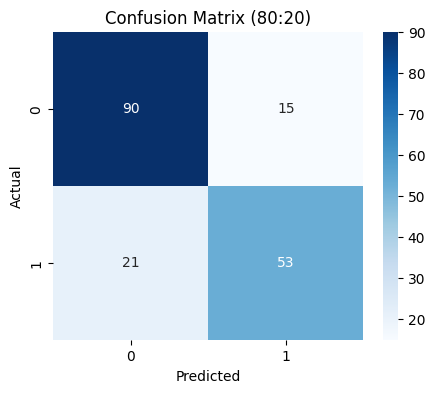

In [27]:
m_80 = confusion_matrix(y_test_80, y_pred_80)

plt.figure(figsize=(5,4))
sns.heatmap(m_80, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

17. 70:30 SPLIT

In [29]:
print("\n===== KNN MODEL (70:30) =====")

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)



===== KNN MODEL (70:30) =====


18. MODEL TRAINING (70:30)

In [30]:
model_70 = KNeighborsClassifier(n_neighbors=5)
model_70.fit(X_train_70, y_train_70)

KNeighborsClassifier()

19. PREDICTION (70:30)

In [31]:
y_pred_70 = model_70.predict(X_test_70)

20. ACCURACY (70:30)

In [32]:
train_acc_70 = model_70.score(X_train_70, y_train_70)
test_acc_70 = accuracy_score(y_test_70, y_pred_70)

print("Training Accuracy:", train_acc_70)
print("Testing Accuracy:", test_acc_70)

Training Accuracy: 0.8539325842696629
Testing Accuracy: 0.7910447761194029


21. CLASSIFICATION REPORT (70:30)

In [33]:
print("\nClassification Report (70:30):\n")
print(classification_report(y_test_70, y_pred_70))


Classification Report (70:30):

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       157
           1       0.80      0.67      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



22. CONFUSION MATRIX (70:30)

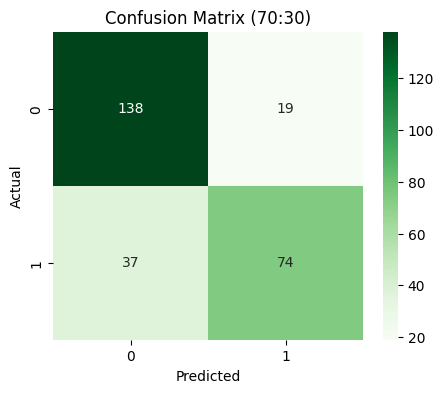

In [34]:
cm_70 = confusion_matrix(y_test_70, y_pred_70)

plt.figure(figsize=(5,4))
sns.heatmap(cm_70, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (70:30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


23. COMPARISON TABLE

In [35]:
print("\n===== FINAL COMPARISON TABLE =====")

results = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Training Accuracy": [train_acc_80, train_acc_70],
    "Testing Accuracy": [test_acc_80, test_acc_70]
})

print(results)


===== FINAL COMPARISON TABLE =====
   Split  Training Accuracy  Testing Accuracy
0  80:20           0.870787          0.798883
1  70:30           0.853933          0.791045


 24. K VALUE ANALYSIS


===== K VALUE ANALYSIS =====


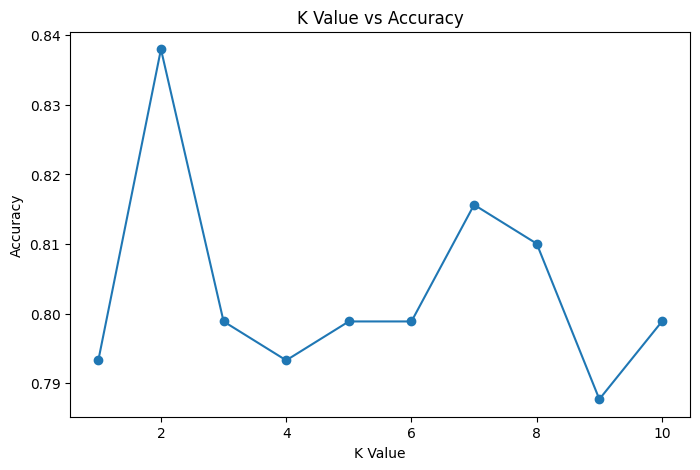

In [36]:
print("\n===== K VALUE ANALYSIS =====")

k_values = list(range(1, 11))
accuracy_list = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_80, y_train_80)
    pred_temp = knn_temp.predict(X_test_80)
    acc = accuracy_score(y_test_80, pred_temp)
    accuracy_list.append(acc)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker='o')
plt.title("K Value vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()


25. SAMPLE PREDICTION

In [37]:
sample = X_scaled[0].reshape(1, -1)
prediction = model_80.predict(sample)

print("\nSample Prediction:", prediction)


Sample Prediction: [0]
